<a href="https://colab.research.google.com/github/jeolin/BCCE_Experiment/blob/main/copper_sulfate_spectral_curve.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Learning Objectives

By working through this notebook, you will be able to:

1.  **Locate and change variables** within pre-written Python code to manipulate experimental parameters.
2.  **Approximate the shape of a typical absorbance spectrum** and understand its key features.
3.  **Identify the absorbance maximum ($\lambda_{max}$)** for various chemical compounds and understand its significance.
4.  **Draw the absorbance spectra of mixtures** of light-absorbing compounds, gaining insight into how multiple components contribute to an overall spectrum.
5.  **Visualize the effect of concentration** on absorbance spectra (coming soon).
6.  **Apply Beer-Lambert Law** principles to quantify concentrations from absorbance data (coming soon).

## Part 1: Introduction to Python Basics

Welcome to your first steps in Python! This notebook will guide you through some fundamental concepts:

### 1. Variables

In Python, a **variable** is like a container for storing information. You give it a name, and then you can store different types of data inside it, such as numbers, text, or lists of items. Think of it like a labeled box where you can put things.

**Example:**
```python
my_number = 10
my_text = "Hello, Python!"
```
Here, `my_number` is a variable holding the number `10`, and `my_text` is a variable holding the string `"Hello, Python!"`.

### 2. Editing Variable Values

You can change the value stored in a variable at any point after it's been created. Simply assign a new value to the same variable name.

**Example:**
```python
# Initial value
score = 0
print(score) # Output: 0

# Update the value
score = 100
print(score) # Output: 100
```

### 3. Executing Code Cells

In this environment (Colab), your code is organized into **cells**. To see the effects of your code, especially when you change variable values, you need to **execute** the cell. Here's how:

*   **Run a cell:** Click the "Play" button (▶) to the left of the cell.
*   **Keyboard Shortcut:** Select the cell and press `Shift + Enter`.

When a cell executes, Python runs all the code within it from top to bottom. If you modify a variable's value in one cell, you'll need to re-run that cell (and any subsequent cells that depend on that variable) to see the updated results.

Let's start exploring!

## Part 2: Chemical Compounds for Spectroscopic Study

Here are five chemical compounds that exhibit distinct absorption maxima ($\lambda_{max}$) within the visible light spectrum. These choices are designed to provide a range of colors and absorption profiles for your experiments.

Visible light ranges approximately from 380 nm (violet) to 750 nm (red).

1.  **Tartrazine (Yellow Food Dye)**
    *   **Approximate $\lambda_{max}$:** ~425 nm (absorbs strongly in the violet-blue region)
    *   **Appearance:** Yellow in solution.

2.  **Copper(II) Sulfate (CuSO$_4$)**
    *   **Approximate $\lambda_{max}$:** ~600-620 nm (absorbs in the orange-red region)
    *   **Appearance:** Blue in aqueous solution.

3.  **Potassium Permanganate (KMnO$_4$)**
    *   **Approximate $\lambda_{max}$:** ~525 nm (absorbs in the green-yellow region)
    *   **Appearance:** Intense purple in solution.

4.  **Cobalt(II) Chloride (CoCl$_2$)**
    *   **Approximate $\lambda_{max}$:** ~510 nm (absorbs in the green region)
    *   **Appearance:** Pink/red in aqueous solution.

5.  **Nickel(II) Sulfate (NiSO$_4$)**
    *   **Approximate $\lambda_{max}$:** ~720 nm (absorbs in the red-far red region)
    *   **Appearance:** Green in aqueous solution.

Continue reading in the next block of text.  You'll notice, however, that the format of the text changes.  This is a result of a shift from this "text block" to a "code block".  Note that throughout this activity, explanations and instructions to you, the student, are included at the top of every code block...so don't ignore them!

In [1]:
# Now that we've set the stage for your introductory work, let's begin by
#   visualizing the spectra for each of these compounds.
# In the code below these introductory remarks, you'll see an index of values
#   that connect each compound with a variable from 1 to 5, where
#
#      1 = Tartrazine
#      2 = Copper Sulfate
#      3 = Potassium Permanganate
#      4 = Cobalt Chloride
#      5 = Nickel Sulfate
#
# Change the variable below to a value between 1 and 5 to make your choice.
# Ensure your choice is enclosed in double quotes (e.g., "1", "2").
# Then run the code in this block to lock-in your choice (set the variable).

cmpd_choice = "4"

# Note that students should not change any code below this line. To view the
#   output of the code you've run, scroll down to the results displayed below
#   this code block.
#
# Define compound names for feedback

import numpy as np

compound_names_map = {
    "1": "Tartrazine",
    "2": "Copper Sulfate",
    "3": "Potassium Permanganate",
    "4": "Cobalt Chloride",
    "5": "Nickel Sulfate"
}

# Check the type of cmpd_choice first
if isinstance(cmpd_choice, int):
    print("""Please restore the double quotes around your number choice.
This code stores your choice as a string (a sequence of characters);
therefore, please enter your choice as "n" (e.g., "1") with the quotation marks.""")
elif cmpd_choice == "0":
    print("""You've run the code in this block without changing the variable
from 0 to a value between 1 and 5. Please locate the line where the variable
(cmpd_choice) is defined and change the value of that variable from 0 to a
positive integer (e.g., "1") within the quotation marks.""")
elif cmpd_choice in compound_names_map:
    chosen_compound = compound_names_map[cmpd_choice]
    print(f"""You have chosen {chosen_compound}.
Continue on to the next code block to explore its visible absorbance spectrum.""")
else:
    print("""Invalid choice. Please enter a number between 1 and 5 (inclusive)
as a string, e.g., "1", "2", "3", "4", or "5".""")

# The generate_spectrum function has been moved here from cell 0f781bed
def generate_spectrum(compound_id):
    # Define parameters for each compound's synthetic spectrum
    # These are illustrative and designed to meet the specified lambda_max ranges
    compounds_data = {
        1: {'name': 'Tartrazine', 'lambda_max': 425, 'fwhm': 50, 'amplitude': 0.8},
        2: {'name': 'Copper(II) Sulfate', 'lambda_max': 600, 'fwhm': 80, 'amplitude': 0.6},
        3: {'name': 'Potassium Permanganate', 'lambda_max': 525, 'fwhm': 60, 'amplitude': 0.9},
        4: {'name': 'Cobalt(II) Chloride', 'lambda_max': 510, 'fwhm': 70, 'amplitude': 0.5},
        5: {'name': 'Nickel(II) Sulfate', 'lambda_max': 720, 'fwhm': 90, 'amplitude': 0.7}  # Corrected compound name
    }

    if compound_id not in compounds_data:
        raise ValueError("Invalid compound_id. Choose between 1 and 5.")

    data = compounds_data[compound_id]
    compound_name = data['name']
    lambda_max = data['lambda_max']
    fwhm = data['fwhm'] # Full Width at Half Maximum
    amplitude = data['amplitude']

    # Generate wavelengths from 300 nm to 800 nm (covering visible and a bit beyond)
    wavelengths = np.arange(400, 750, 1)

    # Use a Gaussian function to simulate the absorption peak
    # std_dev = fwhm / (2 * sqrt(2 * ln(2)))
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    absorbances = amplitude * np.exp(-((wavelengths - lambda_max)**2) / (2 * sigma**2))

    # Add a small baseline absorbance to make it more realistic
    absorbances += 0.05

    # Ensure absorbances are not negative
    absorbances[absorbances < 0] = 0

    return wavelengths, absorbances, lambda_max, compound_name

You have chosen Cobalt Chloride.
Continue on to the next code block to explore its visible absorbance spectrum.


### Visualizing Individual Absorption Spectra

The next code block will generate a synthetic absorption spectrum for the chosen compound. The data are generated using the `generate_spectrum` function defined above. The plot will show the spectrum as absobance vs. wavelength (nm) in a dynamically-generated graph in the area below the code.

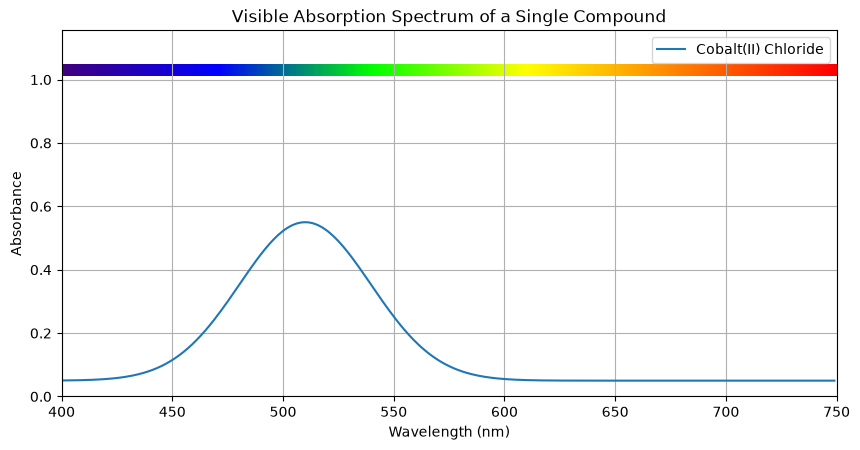

In [2]:
# If this is your first time interacting with this code block, simply run the
#   code and view the results below.  Then, you may return here to change or
#   re-define the choice of compound by changing the value of the cmpd_choice
#   variable, below.  As a reminder,
#
#      1 = Tartrazine
#      2 = Copper Sulfate
#      3 = Potassium Permanganate
#      4 = Cobalt Chloride
#      5 = Nickel Sulfate
#
# Note that the variable definition below is "commented-out" (with a hashtag)
#   so that when this code block is run for the first time, the value of the
#   variable cmpd_choice is not overwritten by your choice in the previous
#   code block.  If, however, you'd like to re-define the variable within this
#   code block, you must "uncomment" it by deleting the hashtag symbol to
#   activate the line of code.  Then, once you've changed your variable
#   declaration, you can re-run this code block to observe the change in the
#   absorbance spectrum.
# One final note about "uncommenting" a line: do not add a space before the
#   variable's name.  If you do, your code will generate an error.  The start
#   of the variable's name must be the very first character of the line.
#
#cmpd_choice = "1"
#
# As before, students should ignore all code below this point.  Furthermore,
#   throughout this activity, any variables we intend for you to interact with
#   will always be defined near the top of a code block in this manner.
#
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Convert cmpd_choice to an integer for function input
selected_compound_id = int(cmpd_choice)

# Generate spectral data using our new function
wavelengths, absorbances, lambda_max_actual, compound_name = generate_spectrum(selected_compound_id)

fig, ax = plt.subplots(figsize=(10, 6)) # Create figure and axes explicitly

# Define visible spectrum colors and their corresponding wavelengths
# These are approximate values for a qualitative visual representation
colors = [
    (0.25, 0.0, 0.5), # Violet (~400 nm)
    (0.0, 0.0, 1.0),  # Blue (~475 nm)
    (0.0, 1.0, 0.0),  # Green (~525 nm)
    (1.0, 1.0, 0.0),  # Yellow (~570 nm)
    (1.0, 0.5, 0.0),  # Orange (~600 nm)
    (1.0, 0.0, 0.0)   # Red (~650 nm)
]

# Create a colormap from these colors
cmap_name = 'VisibleSpectrum'
cmp = mcolors.LinearSegmentedColormap.from_list(cmap_name, colors)

# Create the color bar at the top of the plot area
# The extent defines the x-range (wavelengths) and y-range (arbitrary height for the bar)
ax.imshow(
    [np.arange(400, 751)], # Data for the color bar
    cmap=cmp,
    aspect='auto',
    extent=[400, 750, ax.get_ylim()[1]*1.01, ax.get_ylim()[1]*1.05], # Use ax.get_ylim()
    interpolation='bicubic'
)

# Plot the spectrum
ax.plot(wavelengths, absorbances, label={compound_name})

# Highlight lambda_max
# plt.axvline(x=lambda_max_actual, color='r', linestyle='--', label=rf'$λ_{{max}}$: {lambda_max_actual:.1f} nm')

# Adjust y-limits to make space for the color bar
# Get current y-limits, increase the upper one to make space for the color bar
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.1) # Extend y-axis by 10% to accommodate the color bar

ax.set_title(f'Visible Absorption Spectrum of a Single Compound')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorbance')
ax.legend()
ax.grid(True)

# Adjust figure margins to make space for text below
plt.subplots_adjust(bottom=0.27) # Increased bottom margin for more space

plt.show()

## Identifying Lambda Max (λmax) with an Interactive Slider

Now that you've seen how a compound's absorption spectrum is generated, your next task is to identify its **lambda max (λmax)**. This is the wavelength at which the compound absorbs the most light, and it's a critical characteristic for many analytical techniques.

In the plot below, you'll find an interactive slider. Drag the slider to move the red dashed vertical line across the spectrum. Your goal is to position this line at the peak of the absorption curve, thereby identifying the λmax for your chosen compound. The wavelength value corresponding to the slider's position will be displayed.

Once you've found the λmax, compare it to the approximate values provided in the "Chemical Compounds for Spectroscopic Study" section.

### Enable Interactive Matplotlib Widgets

To make the slider below interactive, you need to run the following magic command once. This command tells `matplotlib` to use an interactive backend suitable for Jupyter/Colab notebooks. After running the cell below, please re-run the code cell containing the interactive plot (cell `3b4c8961`) for the slider to become active.

In [3]:
# It seems that `ipympl` is not being properly registered. This often means that
# `matplotlib` or `ipykernel` itself needs to be updated to ensure compatibility.
# This cell upgrades these packages to their latest versions.
from google.colab import output
output.enable_custom_widget_manager()
!pip install --upgrade -q matplotlib ipykernel
# This magic command enables interactive matplotlib plots in the notebook
!pip install --upgrade -q ipympl
%matplotlib widget
# IMPORTANT: After running this cell, you MUST restart the Colab runtime
# (from the 'Runtime' menu, select 'Restart runtime...') for the changes
# to take effect. Then, re-run all cells.


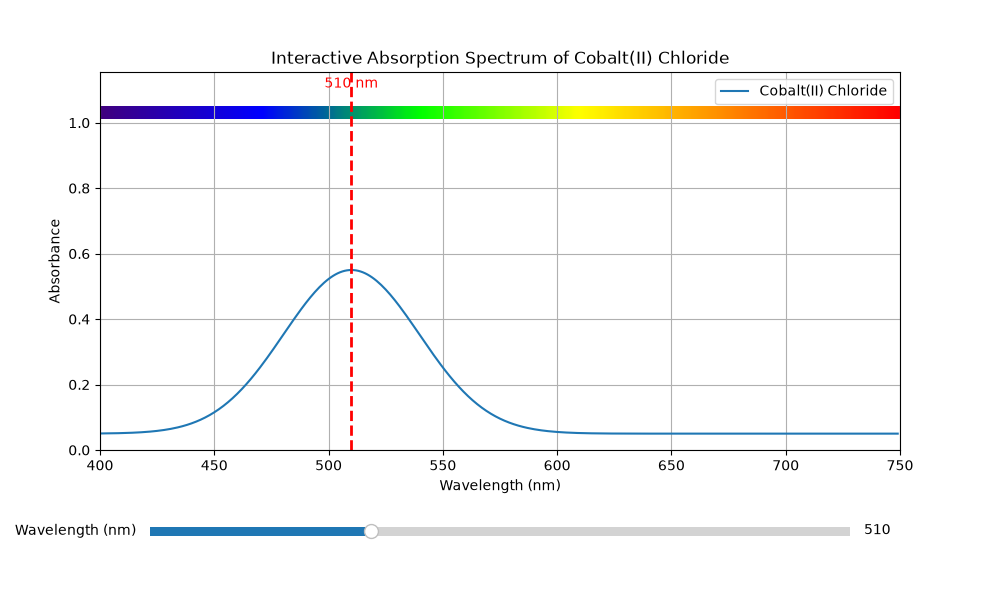

In [9]:
# If this is your first time interacting with this code block, simply run the
#   code and view the results below.  Then, you may return here to change or
#   re-define the choice of compound by changing the value of the cmpd_choice
#   variable, below.
#
# Reminder that...
#   1=Tartrazine
#   2=Copper Sulfate
#   3=Potassium Permanganate
#   4=Cobalt Chloride
#   5=Nickel Sulfate
#
# Note that the variable definition below is "commented-out" (with a hashtag)
#   so that when this code block is run for the first time, its value doesn't
#   overwrite your previous declaration of that same variable.  If, however,
#   you'd like to re-define the variable within this code block, you must
#   "uncomment" it by deleting the hashtag symbol to activate the line of code.
#   Then, once you've changed your variable declaration, you can re-run this
#   code block to observe the change in the absorbance spectrum.
# One final note about "uncommenting" a line: do not add a space before the
#   variable's name.  If you do, your code will generate an error.  The start
#   of the variable's name must be the very first character of the line.
#
#cmpd_choice = "1"
#
# As before, students should ignore all code below this point.  Furthermore,
#   throughout this activity, any variables we intend for you to interact with
#   will always be defined near the top of a code block in this manner.
#
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.widgets import Slider

# Convert cmpd_choice to an integer for function input
selected_compound_id = int(cmpd_choice)

# Generate spectral data using our new function (assuming generate_spectrum is defined globally)
wavelengths, absorbances, lambda_max_actual, compound_name = generate_spectrum(selected_compound_id)

# Create figure and a set of subplots
# Adjust bottom margin to make space for the slider widget
fig, ax = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(left=0.1, bottom=0.25)

# Define visible spectrum colors and their corresponding wavelengths
colors = [
    (0.25, 0.0, 0.5), # Violet (~400 nm)
    (0.0, 0.0, 1.0),  # Blue (~475 nm)
    (0.0, 1.0, 0.0),  # Green (~525 nm)
    (1.0, 1.0, 0.0),  # Yellow (~570 nm)
    (1.0, 0.5, 0.0),  # Orange (~600 nm)
    (1.0, 0.0, 0.0)   # Red (~650 nm)
]

# Create a colormap from these colors
cmap_name = 'VisibleSpectrum'
cmp = mcolors.LinearSegmentedColormap.from_list(cmap_name, colors)

# Create the color bar at the top of the plot area
ax.imshow(
    [np.arange(400, 751)], # Data for the color bar
    cmap=cmp,
    aspect='auto',
    extent=[400, 750, ax.get_ylim()[1]*1.01, ax.get_ylim()[1]*1.05], # Use ax.get_ylim()
    interpolation='bicubic'
)

# Plot the spectrum
ax.plot(wavelengths, absorbances, label=compound_name) # Corrected label here

# Adjust y-limits to make space for the color bar
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.1) # Extend y-axis to accommodate the color bar

ax.set_title(f'Interactive Absorption Spectrum of {compound_name}')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorbance')
ax.legend()
ax.grid(True)

# Create an axes for the slider
ax_slider = plt.axes([0.15, 0.1, 0.7, 0.03]) # [left, bottom, width, height]

# Create the slider widget
# Initialize the slider at the actual lambda_max to give students a hint
slider = Slider(ax_slider,
                'Wavelength (nm)',
                wavelengths.min(),
                wavelengths.max(),
                valinit=lambda_max_actual, # Initial position of the slider
                valstep=1) # Step by 1 nm

# Add an initial vertical line at the slider's starting position
lmbda_line = ax.axvline(x=slider.val, color='r', linestyle='--', lw=2, label='Slider Wavelength')

# Add text annotation for the slider value
slider_text = ax.text(slider.val, ax.get_ylim()[1] * 0.95, f'{slider.val:.0f} nm',
                      color='red', ha='center', va='bottom', fontsize=10)

# Define the function to update the plot when the slider moves
def update(val):
    lmbda_line.set_xdata([val, val]) # Update the x-data of the vertical line
    slider_text.set_position((val, ax.get_ylim()[1] * 0.95))
    slider_text.set_text(f'{val:.0f} nm')
    fig.canvas.draw_idle() # Redraw the figure

# Register the update function with the slider
slider.on_changed(update)

plt.show()

# @title step_artifacts
# num_fig = "1" # @param {type:"string"}
# step = 'LambdaMaxIdentification'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary", "LambdaMaxIdentification"] {type:"string"}
# Assuming `fig` is the current matplotlib figure
# upload_plt_to_gcs(num_fig, step, fig) # Uncomment to save the figure to GCS if needed
